# Trabalho 2 — Processamento de Imagens

Implementa os 4 itens do enunciado (`Trabalho2-2026.pdf`):

1. Filtragem no domínio da frequência: Gaussiano e Butterworth, passa-baixas e
   passa-altas, e aguçamento via passa-altas gaussiano.
2. Extração de componentes conectados via dilatação morfológica (versão
   otimizada, vetorizada).
3. Envoltório convexo (convex hull) via transformada Hit-or-Miss.
4. Segmentação por watershed morfológico.

Toda a lógica de processamento está em `imgproc2/` (sem cv2 — só numpy com
broadcast/`sliding_window_view`). `cv2` é usado **apenas** para ler e salvar
arquivo (`imgproc2/io_utils.py`), conforme combinado.

**Watershed**: não está em nenhuma das 3 aulas do curso (Aula06=frequência,
Aula07/08=morfologia e detecção de bordas — nenhuma cobre watershed).
Implementado com a abordagem distance transform + marcadores, que fica
inteiramente dentro do capítulo de morfologia (ao invés de watershed por
gradiente, que puxaria técnica de detecção de borda de outro capítulo).


In [1]:
import sys, os, time
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt

from imgproc2 import io_utils as io
from imgproc2 import freq_filters as ff
from imgproc2 import morphology as morph
from imgproc2 import connected_components as cc
from imgproc2 import convex_hull as ch
from imgproc2 import watershed as ws

IMG_DIR = "Archive"
np.set_printoptions(suppress=True)


## Item 1 — Filtragem no domínio da frequência

Pipeline (Aula06, slides 30-31): zero-padding para `P=2M,Q=2N`, centralização
via `(-1)^(x+y)` antes da FFT, filtro `H(u,v)` real/simétrico centrado em
`(P/2,Q/2)`, multiplicação `G=H·F`, IDFT, remultiplicação por `(-1)^(x+y)`,
crop `M×N`. Tudo em `imgproc2/freq_filters.py`.

Fórmulas:
- GLPF: `H = exp(-D²/(2·D0²))`
- GHPF: `H = 1 - GLPF`
- BLPF: `H = 1/(1+(D/D0)^(2n))`
- BHPF: `H = 1/(1+(D0/D)^(2n))`


[ WARN:0@0.016] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.016] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.016] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.016] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.016] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.016] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.016] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.016] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

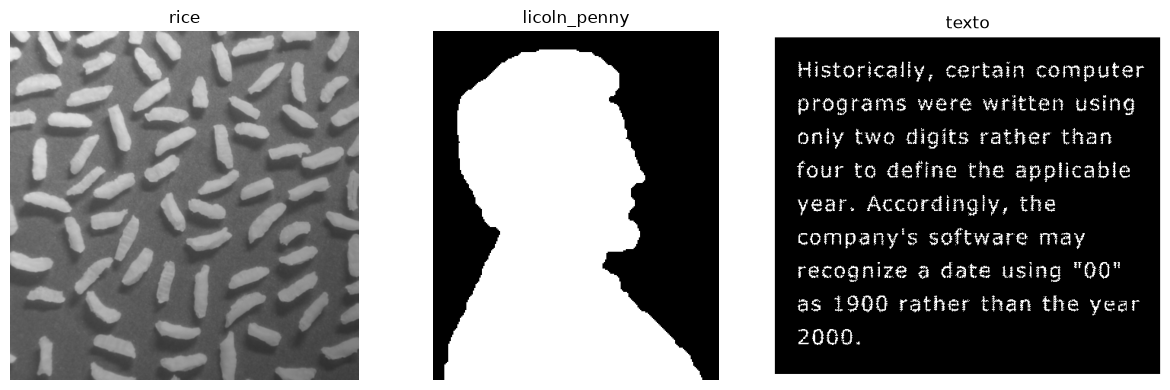

In [2]:
imgs_freq = {
    "rice": io.load_image(f"{IMG_DIR}/rice.tif"),
    "licoln_penny": io.load_image(f"{IMG_DIR}/licoln_penny.tif"),
    "texto": io.load_image(f"{IMG_DIR}/texto.tif"),
}
io.show_grid(list(imgs_freq.values()), titles=list(imgs_freq.keys()))


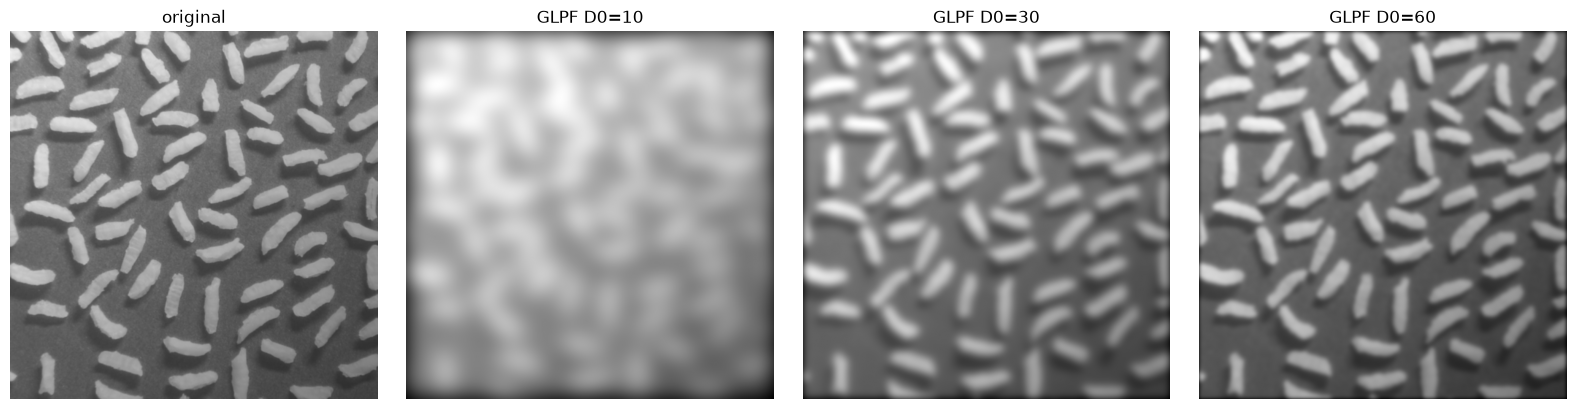

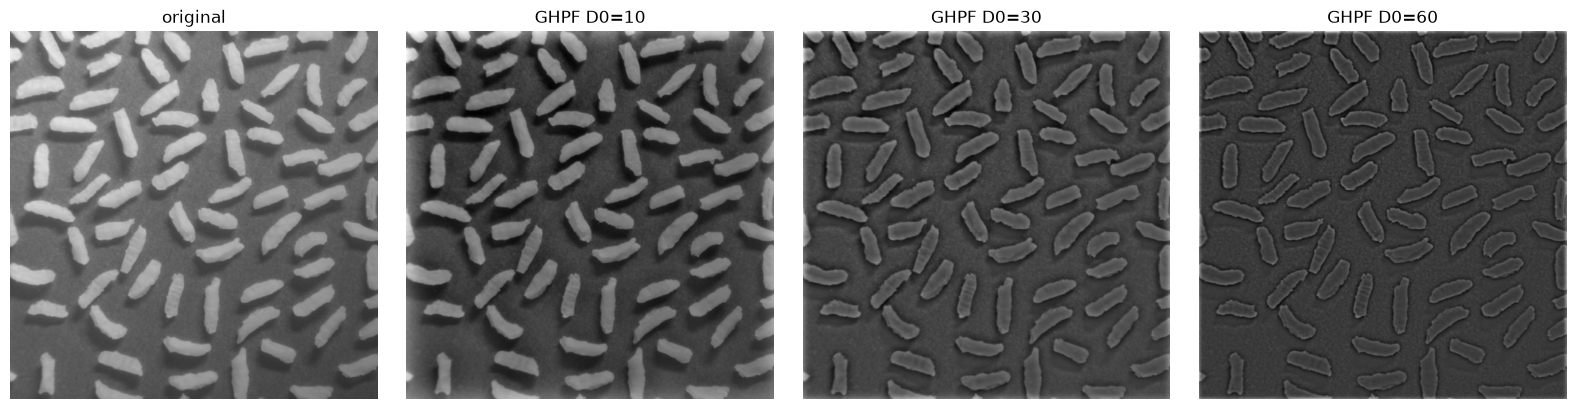

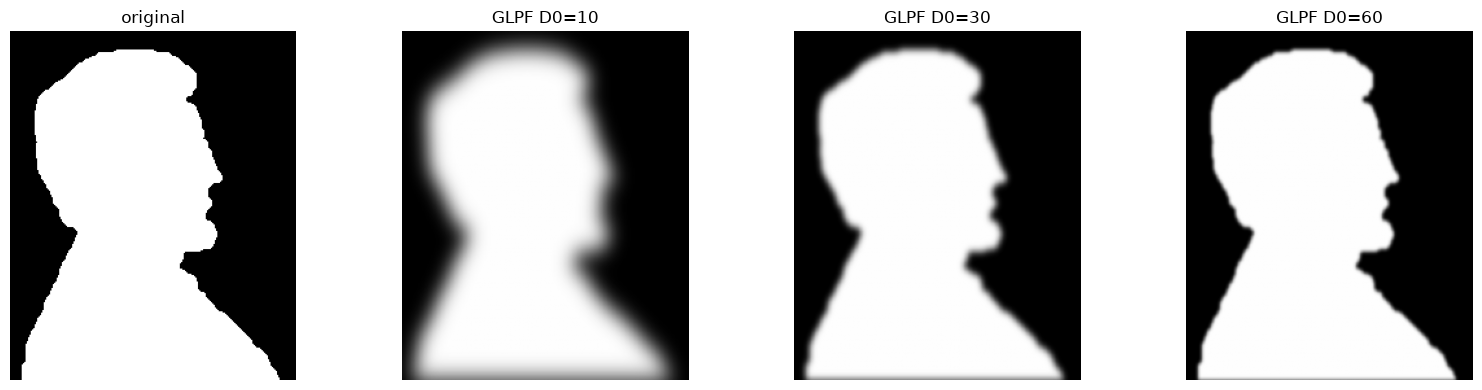

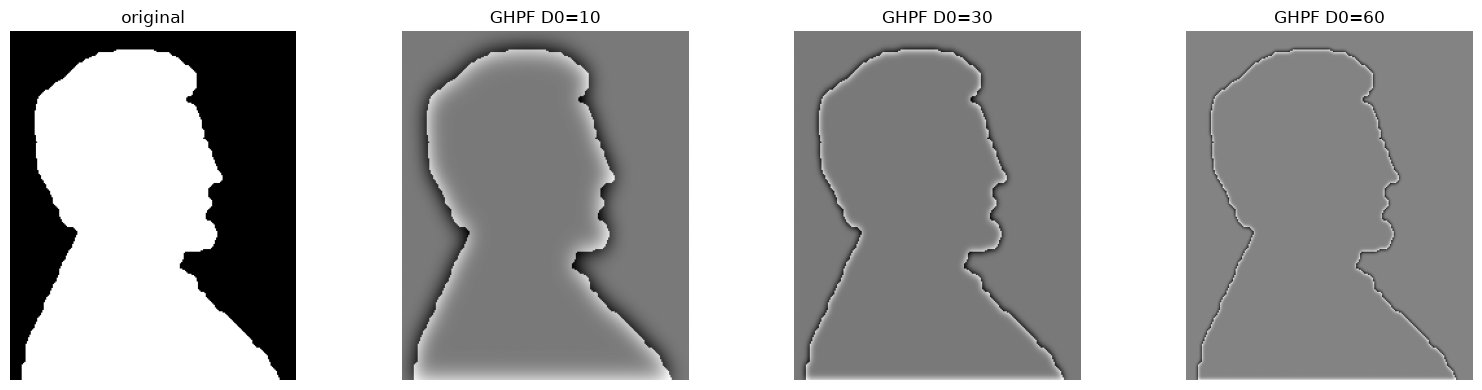

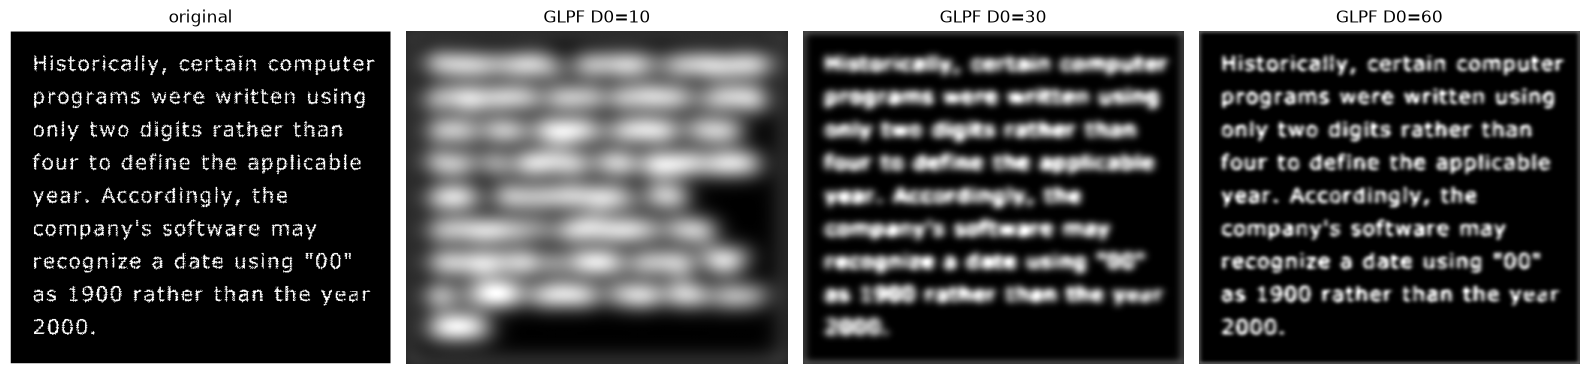

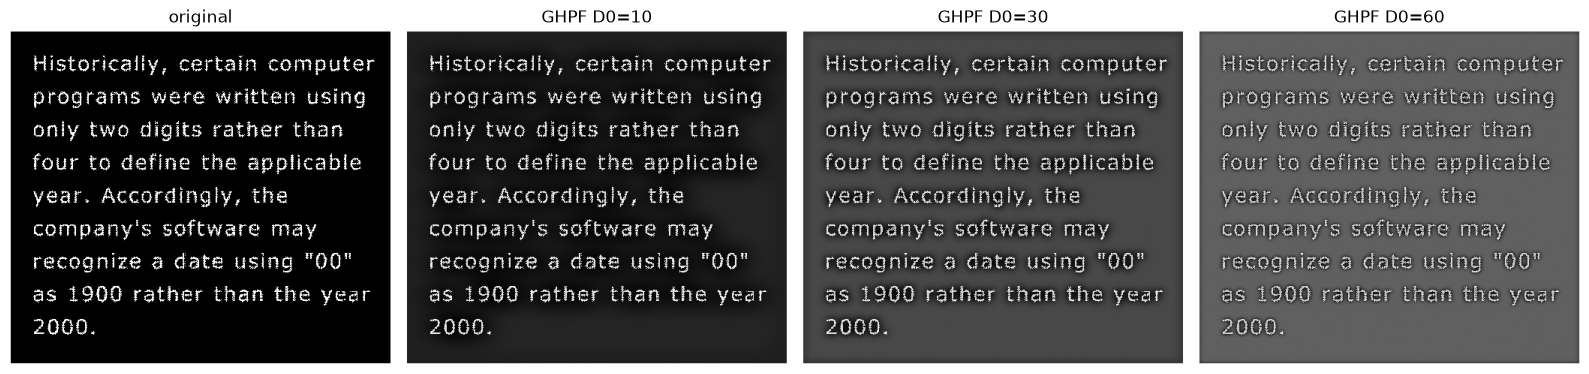

In [3]:
# Gaussiano passa-baixas e passa-altas, variando D0
D0_list = [10, 30, 60]
for name, img in imgs_freq.items():
    lp_results = [img] + [ff.gaussian_filter(img, D0) for D0 in D0_list]
    hp_results = [img] + [ff.gaussian_filter(img, D0, highpass=True) for D0 in D0_list]
    io.show_grid(lp_results, titles=["original"] + [f"GLPF D0={d}" for d in D0_list])
    io.show_grid(hp_results, titles=["original"] + [f"GHPF D0={d}" for d in D0_list])


**Comportamento ao variar D0 (Gaussiano):** D0 pequeno no passa-baixas corta
mais frequências altas → mais borrão (perde detalhe/borda); D0 grande deixa
passar mais frequência → resultado quase idêntico ao original. No passa-altas
é o oposto: D0 pequeno remove pouca frequência baixa → sobra quase só
contorno/textura fina (imagem quase preta com bordas); D0 grande corta mais
baixa frequência → realça estruturas de frequência progressivamente mais
alta.


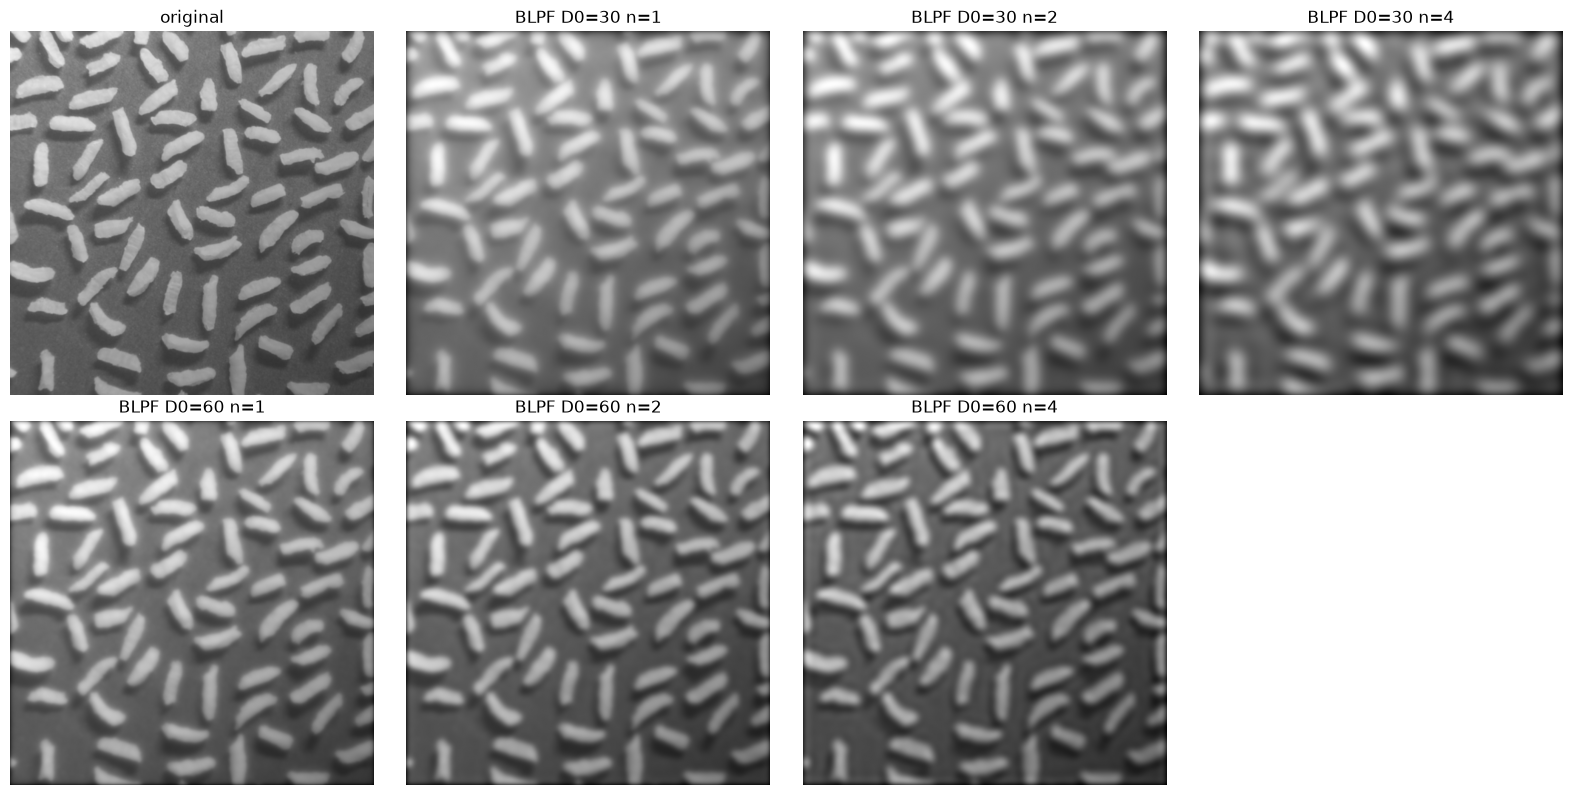

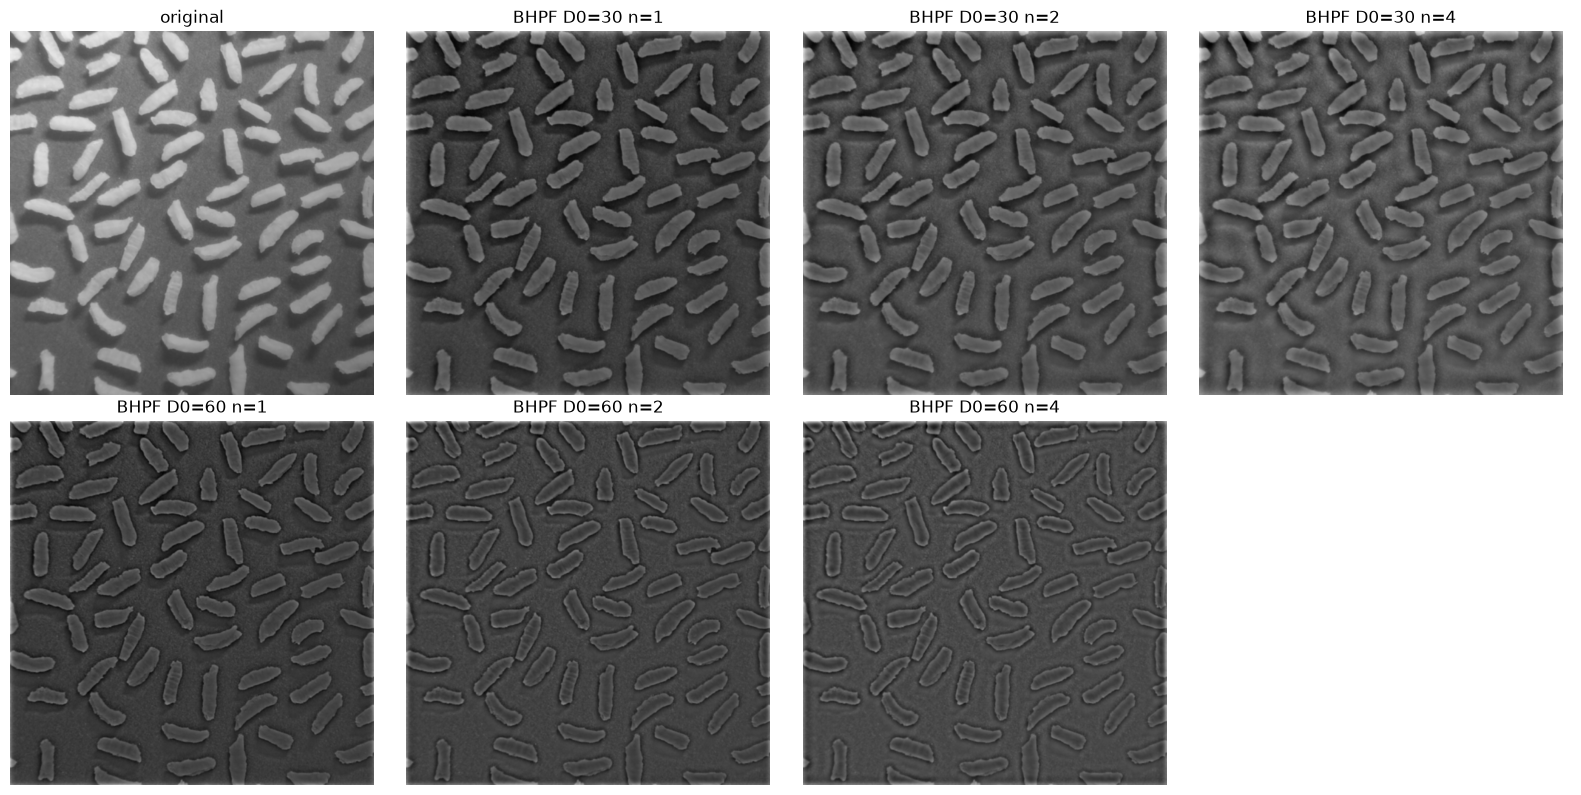

In [4]:
# Butterworth passa-baixas e passa-altas, variando D0 e n
D0_bw = [30, 60]
n_bw = [1, 2, 4]
img = imgs_freq["rice"]
results, titles = [img], ["original"]
for D0 in D0_bw:
    for n in n_bw:
        results.append(ff.butterworth_filter(img, D0, n))
        titles.append(f"BLPF D0={D0} n={n}")
io.show_grid(results, titles=titles, cols=4)

results, titles = [img], ["original"]
for D0 in D0_bw:
    for n in n_bw:
        results.append(ff.butterworth_filter(img, D0, n, highpass=True))
        titles.append(f"BHPF D0={D0} n={n}")
io.show_grid(results, titles=titles, cols=4)


**Comportamento ao variar D0 e n (Butterworth):** D0 controla a frequência de
corte (mesmo efeito do Gaussiano — D0 baixo corta mais). `n` controla a
"suavidade" da transição: `n` baixo (≈1) aproxima o Butterworth do Gaussiano
(transição suave, sem artefatos); `n` alto (≥4) aproxima do filtro ideal
(corte abrupto), o que introduz **ringing** (anéis concêntricos visíveis,
efeito Gibbs) nas bordas do resultado — trade-off clássico nitidez de corte
vs. artefato.


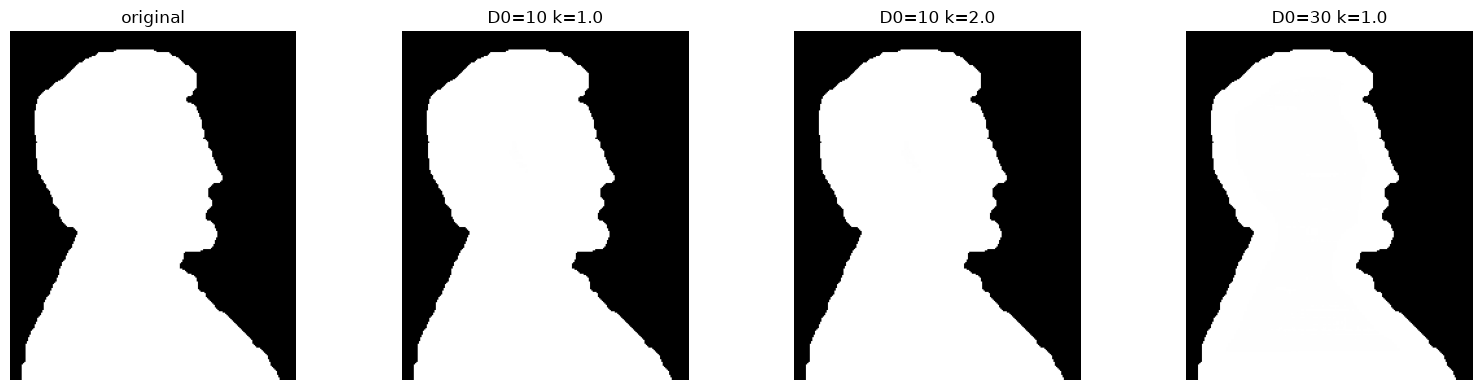

In [5]:
# Aguçamento via passa-altas gaussiano: g = f + k*GHPF(f, D0)
img = imgs_freq["licoln_penny"]
sharpened = [img]
titles = ["original"]
for D0, k in [(10, 1.0), (10, 2.0), (30, 1.0)]:
    sharpened.append(ff.highboost_sharpen(img, D0=D0, k=k))
    titles.append(f"D0={D0} k={k}")
io.show_grid(sharpened, titles=titles)


**Aguçamento:** como o material do curso define apenas o filtro `H_HP`
(slide 52) sem uma fórmula explícita de aguçamento, usamos a extensão padrão
de Gonzalez: `g = f + k·GHPF(f,D0)` (high-boost). `k` maior → mais realce de
borda (pode saturar); `D0` menor no passa-altas → realça detalhes mais finos.


## Item 2 — Componentes conectados via dilatação morfológica (otimizado)

Algoritmo do slide 45: `X_k=(X_{k-1}⊕B)∩I` até `X_k=X_{k-1}`, um rótulo por
componente. Nossa versão (`connected_components.extract_components`) roda
**todos os componentes simultaneamente**: cada pixel de objeto começa com um
rótulo único; a cada iteração cada pixel adota o **menor rótulo entre os
vizinhos** (dentro de `B`) que também sejam objeto — é a mesma fórmula, só
generalizada de binário (OR) para multi-rótulo (MIN), um único passe
vetorizado por iteração em vez de um passe por componente (o que o notebook
original do professor faz com um loop Python por componente/BFS em `set`).


[ WARN:0@6.306] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


componentes: 55   tempo: 12.90s


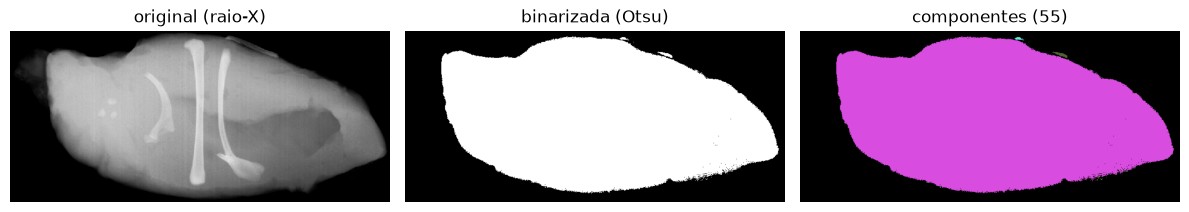

In [6]:
chicken = io.load_image(f"{IMG_DIR}/Fig0918(a)(Chickenfilet with bones).tif")
chicken_bin = io.binarize(chicken)

t0 = time.time()
labels_chicken, n_chicken = cc.extract_components(chicken_bin)
dt = time.time() - t0
print(f"componentes: {n_chicken}   tempo: {dt:.2f}s")

io.show_grid(
    [chicken, chicken_bin, cc.colorize(labels_chicken)],
    titles=["original (raio-X)", "binarizada (Otsu)", f"componentes ({n_chicken})"],
)


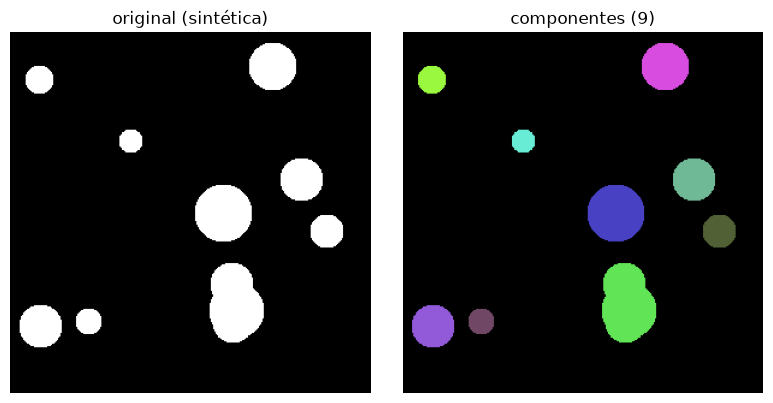

In [7]:
# Segundo teste: círculos sintéticos sobrepostos ao estilo do slide 46
rng = np.random.default_rng(0)
canvas = np.zeros((300, 300), dtype=np.uint8)
yy, xx = np.mgrid[0:300, 0:300]
for _ in range(12):
    cy, cx, r = rng.integers(20, 280), rng.integers(20, 280), rng.integers(10, 25)
    canvas[(yy - cy) ** 2 + (xx - cx) ** 2 < r ** 2] = 255

labels_circ, n_circ = cc.extract_components(canvas)
io.show_grid(
    [canvas, cc.colorize(labels_circ)],
    titles=["original (sintética)", f"componentes ({n_circ})"],
)


**Otimização:** a versão por componente (loop Python, uma dilatação de
imagem inteira por componente por iteração) escala em
`O(nº_componentes × iterações × H×W)`. A versão simultânea acima faz
`O(iterações × H×W)` no total — todos os rótulos propagam juntos em cada
passe de `sliding_window_view`. Ganho cresce com o número de componentes.


## Item 3 — Envoltório convexo via Hit-or-Miss

Slides 48-50: 4 elementos estruturantes `B¹..B⁴` (um por orientação de
canto), `X_k^i=(X_{k-1}^i⊛B^i)∪X_{k-1}^i` até convergência, `C(A)=∪Dⁱ`.

A figura do slide não pôde ser transcrita pixel a pixel com certeza (é uma
imagem pequena); em vez disso, derivamos `B1` a partir da definição do que o
algoritmo precisa detectar — um canto côncavo (vizinhos Norte+Oeste exigidos
objeto, Leste+Sul exigidos fundo) — e geramos `B2,B3,B4` girando `B1` 90° por
vez com `np.rot90` (mesma ideia do slide: cada `Bi` é o anterior rotacionado).
Validamos testando que preenche corretamente um canto côncavo real (célula de
teste abaixo).

Rodamos o algoritmo **por componente**, restrito à bounding box de cada um
(dica do slide 51) — evita o crescimento excessivo além dos limites do
objeto (problema do slide 49).


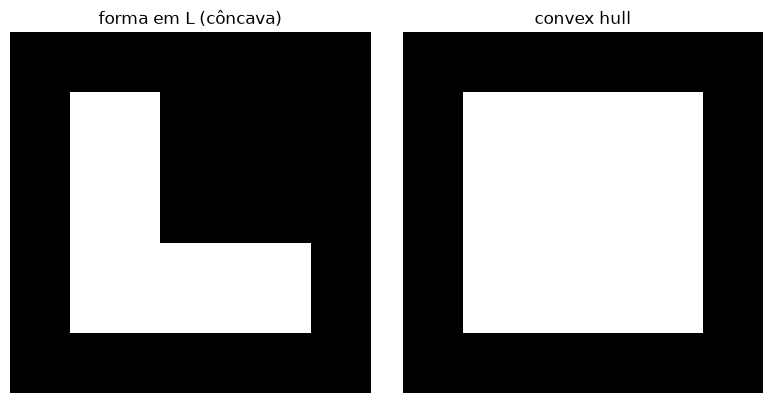

In [8]:
# Validação didática: forma em L (canto côncavo real) -> hull deve virar um retângulo sólido
lshape = np.zeros((12, 12), dtype=np.uint8)
lshape[2:10, 2:5] = 255
lshape[7:10, 2:10] = 255
hull_l = ch.convex_hull_binary(lshape)
io.show_grid([lshape, hull_l], titles=["forma em L (côncava)", "convex hull"])
assert hull_l.sum() > lshape.sum(), "hull deveria crescer para preencher o canto"


tempo hull: 3.78s   componentes: 17


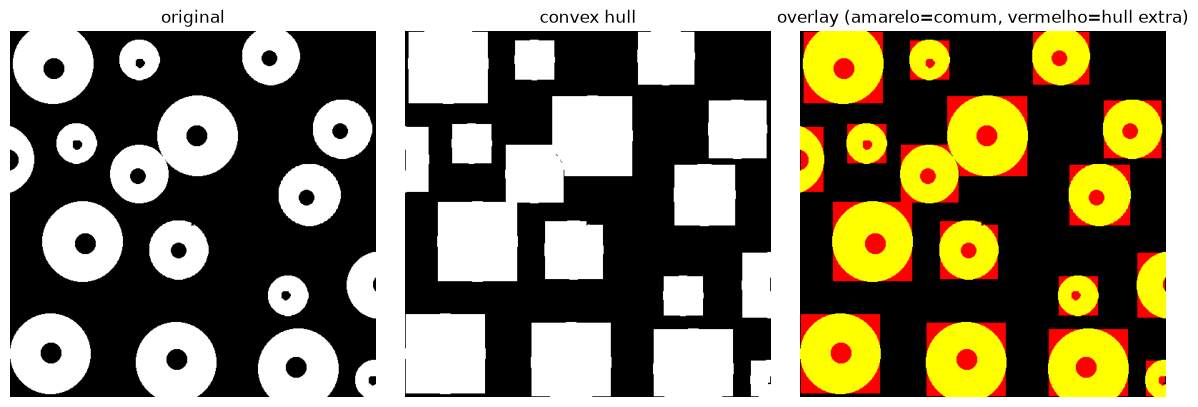

In [9]:
region = io.load_image(f"{IMG_DIR}/region-filling.tif")
region_bin = io.binarize(region)
labels_region, n_region = cc.extract_components(region_bin)

t0 = time.time()
hull_region = ch.convex_hull_per_component(region_bin, labels_region, n_region)
print(f"tempo hull: {time.time()-t0:.2f}s   componentes: {n_region}")

overlay = np.zeros((*region_bin.shape, 3), dtype=np.uint8)
overlay[..., 0] = hull_region        # hull em vermelho
overlay[..., 1] = region_bin         # original em verde -> sobreposição fica amarela
io.show_grid([region_bin, hull_region, overlay],
             titles=["original", "convex hull", "overlay (amarelo=comum, vermelho=hull extra)"])


## Item 4 — Watershed morfológico

Abordagem escolhida: distance transform + marcadores (ver introdução do
notebook para a justificativa). Passos (`imgproc2/watershed.py`):

1. `distance_transform`: nº de erosões que cada pixel sobrevive.
2. Marcadores: `local_maxima` (picos do distance transform) para formas bem
   separadas, ou `threshold_markers` (corte de altura) para formas
   irregulares — ver discussão abaixo.
3. `extract_components` rotula os marcadores.
4. `flood_from_markers`: inundação nível-a-nível; pixel disputado por dois
   rótulos na mesma iteração vira linha de watershed (vermelho no overlay).


marcadores encontrados: 2


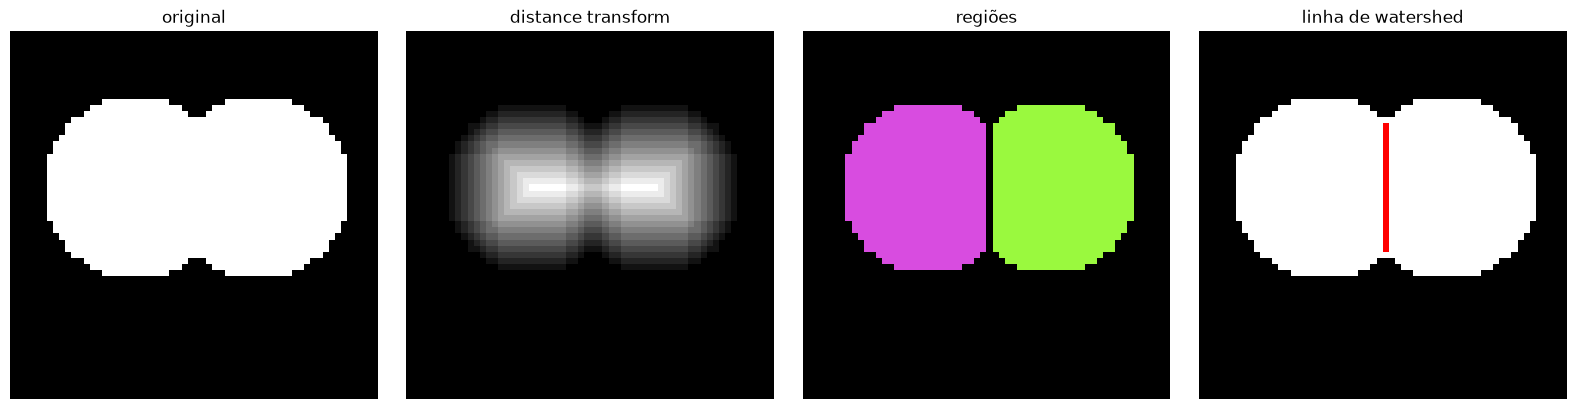

In [10]:
# Caso limpo: dois círculos sintéticos encostados
yy, xx = np.mgrid[0:60, 0:60]
c1 = (yy - 25) ** 2 + (xx - 20) ** 2 < 15 ** 2
c2 = (yy - 25) ** 2 + (xx - 40) ** 2 < 15 ** 2
touching = ((c1 | c2) * 255).astype(np.uint8)

labels_ws, dist_ws, n_ws = ws.watershed_transform(touching)
print("marcadores encontrados:", n_ws)

rgb = np.stack([touching] * 3, axis=-1)
overlay_ws = ws.draw_watershed_lines(rgb, labels_ws)
io.show_grid(
    [touching, io.to_uint8(dist_ws), cc.colorize(np.where(labels_ws < 0, 0, labels_ws)), overlay_ws],
    titles=["original", "distance transform", "regiões", "linha de watershed"],
)


marcadores encontrados: 3


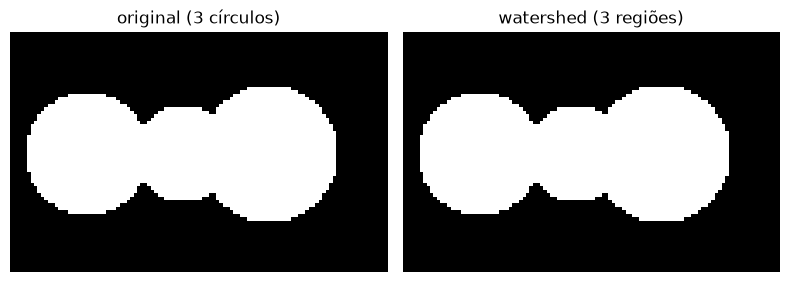

In [11]:
# Caso com 3 círculos de tamanhos diferentes, mostrando que generaliza além de 2 objetos
yy, xx = np.mgrid[0:70, 0:110]
c1 = (yy - 35) ** 2 + (xx - 22) ** 2 < 18 ** 2
c2 = (yy - 35) ** 2 + (xx - 50) ** 2 < 14 ** 2
c3 = (yy - 35) ** 2 + (xx - 75) ** 2 < 20 ** 2
touching3 = ((c1 | c2 | c3) * 255).astype(np.uint8)

labels3, dist3, n3 = ws.watershed_transform(touching3)
print("marcadores encontrados:", n3)
rgb3 = np.stack([touching3] * 3, axis=-1)
io.show_grid(
    [touching3, ws.draw_watershed_lines(rgb3, labels3)],
    titles=["original (3 círculos)", f"watershed ({n3} regiões)"],
)


**rice.tif** (caso clássico de Gonzalez para esse problema) — imagem real,
mais desafiadora: iluminação desigual gera ruído na binarização simples por
Otsu, e o distance transform de grãos alongados/irregulares tem várias
ondulações ao longo da "crista", o que faz `local_maxima` **sobre-segmentar**
bastante (centenas de marcadores espúrios). Usamos `threshold_markers` (corte
de altura do distance transform, mais robusto pra formas irregulares) em vez
de `local_maxima` — resultado bem mais próximo da contagem real de grãos.


distância máxima (raio do maior grão): 19


marcadores via local_maxima: 674   via threshold_markers: 74


regiões finais (grãos separados): 74


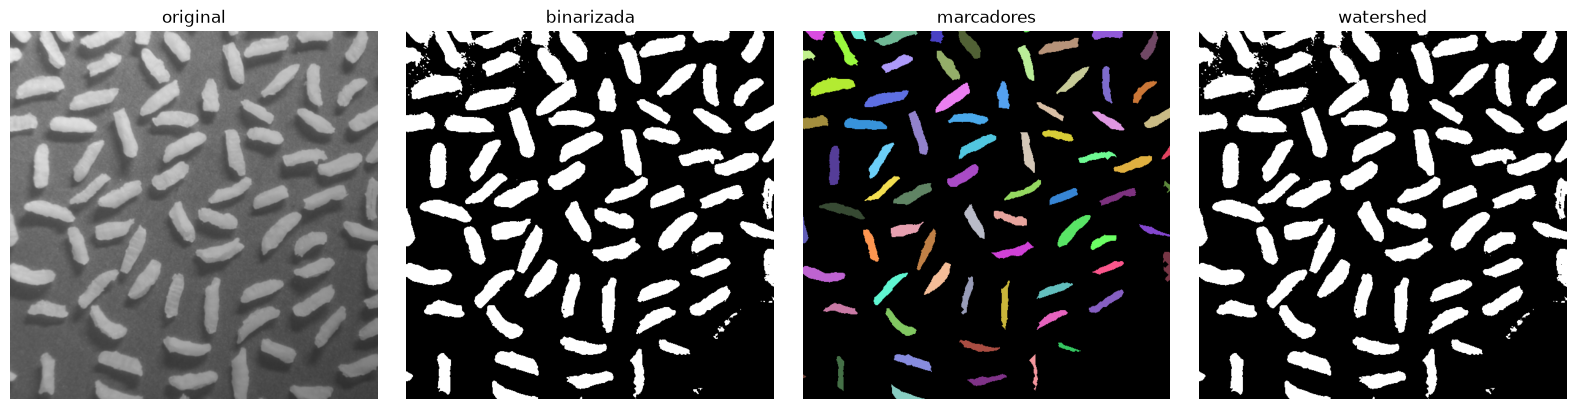

In [12]:
rice = io.load_image(f"{IMG_DIR}/rice.tif")
rice_bin = io.binarize(rice)

dist_rice = ws.distance_transform(rice_bin)
print("distância máxima (raio do maior grão):", dist_rice.max())

# comparação: local_maxima (sobre-segmenta) vs threshold_markers (mais robusto)
maxima_mask = ws.local_maxima(dist_rice, size=7)
markers_lm, n_lm = cc.extract_components((maxima_mask * 255).astype(np.uint8))
markers_th = ws.threshold_markers(dist_rice, level=5, min_size=8)
print(f"marcadores via local_maxima: {n_lm}   via threshold_markers: {markers_th.max()}")

labels_rice, _, n_rice = ws.watershed_transform(rice_bin, dist=dist_rice, markers=markers_th)
print("regiões finais (grãos separados):", n_rice)

rgb_rice = np.stack([rice_bin] * 3, axis=-1)
io.show_grid(
    [rice, rice_bin, cc.colorize(markers_th), ws.draw_watershed_lines(rgb_rice, labels_rice)],
    titles=["original", "binarizada", "marcadores", "watershed"],
)


**Conclusão item 4:** nos grãos de arroz já bem separados pela binarização,
o watershed praticamente reproduz os componentes conectados (poucos ou
nenhum grão realmente encostado nessa binarização específica) — o valor do
método aparece nos casos sintéticos acima, onde os objetos se tocam de
verdade e o algoritmo precisa decidir a fronteira. Isso é esperado e
documentado: `local_maxima` puro (a abordagem "livro-texto" mais simples) é
conhecida por sobre-segmentar em formas irregulares — é exatamente o motivo
histórico de existirem técnicas de marcador mais robustas (h-minima,
marcadores impostos manualmente) em implementações de produção, fora do
escopo deste trabalho.
